# **Gastric Cancer Classification**

**GPU Check**

In [3]:
import torch

if torch.cuda.is_available():
    gpu_name       = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"GPU: {gpu_name}  (Capability: {gpu_capability})")
    if gpu_capability[0] < 7:
        print("⚠️  WARNING: Your GPU is too old for this PyTorch version. "
              "Switch to a T4 or L4 GPU in Settings.")
    else:
        print("✅ SUCCESS: GPU is compatible!")
else:
    print("❌ No GPU detected. Please enable a T4 / L4 GPU in Settings.")

GPU: Tesla T4  (Capability: (7, 5))
✅ SUCCESS: GPU is compatible!


**Imports**

In [4]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets import ImageFolder
from torchvision.models import (
    efficientnet_b0,  EfficientNet_B0_Weights,
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    vit_b_16,         ViT_B_16_Weights,
)

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from tqdm.auto import tqdm

print("All libraries imported successfully.")

All libraries imported successfully.


**Constants & Hyperparameters**

In [15]:
# ── Image / training settings ──────────────────────────────────────────────
IMG_SIZE    = (224, 224)
NUM_GPUS = torch.cuda.device_count()
BASE_BATCH = 64
BATCH_SIZE = BASE_BATCH * max(1, NUM_GPUS)  # Scales automatically
VIT_BATCH = 32 * max(1, NUM_GPUS)
LR          = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS      = 30
PATIENCE    = 5           # early-stopping patience


# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/azmainofficial/gastric-cancer/all_image'
SAVE_DIR = '/kaggle/working/saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# NUM_CLASSES is set dynamically after the dataset is loaded (see Cell 5)
NUM_CLASSES = None

print(f"Device  : {DEVICE}")
print(f"Save dir: {SAVE_DIR}")

Device  : cuda
Save dir: /kaggle/working/saved_models


**Data Transforms**

In [8]:
# ImageNet normalisation constants (shared by all models)
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]


def get_efficientnet_train_transforms(img_size=IMG_SIZE):
    """Augmented transforms for EfficientNet training."""
    return transforms.Compose([
        transforms.Resize(img_size),
        transforms.RandomAffine(degrees=20, translate=(0.2, 0.2), scale=(0.8, 1.2)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=_MEAN, std=_STD),
    ])


def get_efficientnet_val_transforms(img_size=IMG_SIZE):
    """Minimal transforms for EfficientNet validation / inference."""
    return transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=_MEAN, std=_STD),
    ])


def get_vit_train_transforms():
    """Augmented transforms for ViT-B/16 training."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=_MEAN, std=_STD),
    ])


def get_vit_val_transforms():
    """Minimal transforms for ViT-B/16 validation / inference."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=_MEAN, std=_STD),
    ])


print("✅ Transforms defined.")

✅ Transforms defined.


**Dataset & DataLoader**

In [9]:
class TransformedDataset(Dataset):
    """Applies a transform to a torch Subset."""

    def __init__(self, subset, transform=None):
        self.subset    = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


def create_loaders(folder_path, val_split=0.2, model_type='efficientnet'):
    """
    Build train and validation DataLoaders.

    Args:
        folder_path : Path to an ImageFolder-compatible directory.
        val_split   : Fraction of data used for validation.
        model_type  : 'efficientnet'  → 224×224, batch 32
                      'vit'           → resize-256/crop-224, batch 16

    Returns:
        train_loader, val_loader, num_classes
    """
    global NUM_CLASSES

    full_dataset = ImageFolder(root=folder_path)
    num_classes  = len(full_dataset.classes)
    print(f"Classes found : {num_classes}")
    print(f"Class names   : {full_dataset.classes}")
    print(f"Total images  : {len(full_dataset)}")

    val_size   = int(len(full_dataset) * val_split)
    train_size = len(full_dataset) - val_size
    train_subset, val_subset = random_split(
        full_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    # Pick transforms and batch size based on model family
    if model_type == 'vit':
        train_tfm  = get_vit_train_transforms()
        val_tfm    = get_vit_val_transforms()
        batch_size = VIT_BATCH
    else:
        train_tfm  = get_efficientnet_train_transforms()
        val_tfm    = get_efficientnet_val_transforms()
        batch_size = BATCH_SIZE

    train_data = TransformedDataset(train_subset, transform=train_tfm)
    val_data   = TransformedDataset(val_subset,   transform=val_tfm)

    train_loader = DataLoader(
        train_data, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_data, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )

    NUM_CLASSES = num_classes          # update global
    print(f"\nNUM_CLASSES set to: {NUM_CLASSES}")
    return train_loader, val_loader, num_classes


# ── Create EfficientNet loaders (default) ──────────────────────────────────
train_loader, val_loader, NUM_CLASSES = create_loaders(DATA_DIR, model_type='efficientnet')

Classes found : 8
Class names   : ['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']
Total images  : 31096

NUM_CLASSES set to: 8


**Model Architecture**

In [10]:
class CustomModel(nn.Module):
    """
    Transfer-learning wrapper for EfficientNet-B0, EfficientNet-V2-S,
    and ViT-B/16 with a custom classification head.
    """

    def __init__(self, model_type: str = 'b0', num_classes: int = None):
        super().__init__()

        if num_classes is None:
            if NUM_CLASSES is None:
                raise ValueError(
                    "NUM_CLASSES is not set. Run create_loaders() first, "
                    "or pass num_classes explicitly."
                )
            num_classes = NUM_CLASSES

        if model_type == 'b0':
            backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
            in_ftrs  = backbone.classifier[1].in_features
            backbone.classifier[1] = nn.Sequential(
                nn.Dropout(p=0.3, inplace=True),
                nn.Linear(in_ftrs, num_classes),
            )

        elif model_type == 'v2_s':
            backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
            in_ftrs  = backbone.classifier[1].in_features
            backbone.classifier[1] = nn.Sequential(
                nn.Dropout(p=0.3, inplace=True),
                nn.Linear(in_ftrs, num_classes),
            )

        elif model_type == 'vit':
            backbone = vit_b_16(weights=ViT_B_16_Weights.DEFAULT)
            in_ftrs  = backbone.heads.head.in_features
            backbone.heads.head = nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_ftrs, num_classes),
            )

        else:
            raise ValueError(
                f"Unknown model_type '{model_type}'. "
                "Choose from: 'b0', 'v2_s', 'vit'."
            )

        self.model = backbone

    def forward(self, x):
        return self.model(x)


print("✅ CustomModel defined (supports: 'b0', 'v2_s', 'vit').")

✅ CustomModel defined (supports: 'b0', 'v2_s', 'vit').


**Evaluation Metrics**

In [11]:
def calculate_metrics(predictions, labels, num_classes=None):
    """
    Compute Accuracy, Macro AUC-ROC, and Macro F1.

    Args:
        predictions : List / array of softmax probability vectors.
        labels      : List / array of ground-truth integer labels.
        num_classes : Number of classes (defaults to global NUM_CLASSES).

    Returns:
        (accuracy, auc_score, f1_score) as floats.
    """
    if num_classes is None:
        num_classes = NUM_CLASSES

    preds_prob  = np.array(predictions)      # shape: (N, C)
    preds_class = np.argmax(preds_prob, axis=1)
    labels      = np.array(labels)

    accuracy = accuracy_score(labels, preds_class)

    try:
        auc = roc_auc_score(
            labels, preds_prob,
            multi_class='ovr',
            labels=list(range(num_classes)),
            average='macro',
        )
    except Exception as exc:
        print(f"AUC computation error: {exc}")
        auc = 0.0

    f1 = f1_score(labels, preds_class, average='macro', zero_division=0)
    return accuracy, auc, f1


print("✅ calculate_metrics() defined.")

✅ calculate_metrics() defined.


Training Loop

In [12]:
def run_training(model_type: str = 'b0'):
    """
    Train a CustomModel with multi-GPU support and return the model + history dict.

    Args:
        model_type: 'b0' | 'v2_s' | 'vit'

    Returns:
        model   : Trained nn.Module (may be wrapped with DataParallel).
        history : Dict with lists for train_loss, val_loss,
                  val_acc, val_auc, val_f1.
    """
    print(f"\n{'='*60}")
    print(f"  Training  {model_type.upper()}")
    print(f"{'='*60}")

    # ── Build loaders with the correct transforms ──────────────
    t_loader, v_loader, _ = create_loaders(DATA_DIR, model_type=(
        'vit' if model_type == 'vit' else 'efficientnet'
    ))

    # ── Model, optimiser, scheduler, loss ─────────────────────
    model     = CustomModel(model_type).to(DEVICE)
    
    # ── Apply multi-GPU wrapping ──────────────────────────────
    if torch.cuda.device_count() > 1:
        print(f"\n🚀 Wrapping model with DataParallel ({torch.cuda.device_count()} GPUs)...")
        model = nn.DataParallel(model)
        print(f"✅ Model wrapped successfully!\n")
    
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_val_loss    = float('inf')
    patience_counter = 0
    save_path        = os.path.join(SAVE_DIR, f'best_model_{model_type}.pth')

    history = {
        'train_loss': [], 'val_loss': [],
        'val_acc': [], 'val_auc': [], 'val_f1': [],
    }

    for epoch in range(1, EPOCHS + 1):

        # ── Training phase ────────────────────────────────────
        model.train()
        train_loss = 0.0
        for images, labels in tqdm(t_loader, desc=f"Ep {epoch:02d} Train", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)

        scheduler.step()

        # ── Validation phase ──────────────────────────────────
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for images, labels in tqdm(v_loader, desc=f"Ep {epoch:02d} Val  ", leave=False):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs   = model(images)
                val_loss += criterion(outputs, labels).item() * images.size(0)
                probs     = torch.softmax(outputs, dim=1)
                val_preds.extend(probs.cpu().tolist())
                val_labels.extend(labels.cpu().tolist())

        # ── Metrics ───────────────────────────────────────────
        t_loss = train_loss / len(t_loader.dataset)
        v_loss = val_loss   / len(v_loader.dataset)
        v_acc, v_auc, v_f1 = calculate_metrics(val_preds, val_labels)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['val_auc'].append(v_auc)
        history['val_f1'].append(v_f1)

        print(
            f"Ep {epoch:02d} | "
            f"Loss {t_loss:.4f}/{v_loss:.4f} | "
            f"Acc {v_acc:.4f} | AUC {v_auc:.4f} | F1 {v_f1:.4f} | "
            f"LR {scheduler.get_last_lr()[0]:.6f}"
        )

        # ── Checkpoint & early stopping ───────────────────────
        if v_loss < best_val_loss:
            best_val_loss    = v_loss
            patience_counter = 0
            
            # ── Save the underlying module (not DataParallel wrapper) ─
            model_to_save = model.module if isinstance(model, nn.DataParallel) else model
            
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model_to_save.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss':             v_loss,
                'val_acc':              v_acc,
            }, save_path)
            print(f"    ✅ Best model saved (val_loss={v_loss:.4f})")
        else:
            patience_counter += 1
            print(f"    ⏳ No improvement ({patience_counter}/{PATIENCE})")
            if patience_counter >= PATIENCE:
                print(f"    🛑 Early stopping at epoch {epoch}")
                break

    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} done | Best val loss: {best_val_loss:.4f}")
    print(f"{'='*60}\n")
    return model, history


print("✅ run_training() defined with multi-GPU support.")

✅ run_training() defined with multi-GPU support.


**Training History Plots**

In [13]:
def plot_history(history: dict, model_name: str = 'Model'):
    """
    Plot training / validation loss, accuracy, AUC-ROC, and F1
    for a single training run with multi-GPU training info.

    Args:
        history    : Dict returned by run_training().
        model_name : Display name used in the figure title and saved filename.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    best_ep = {
        'acc' : int(np.argmax(history['val_acc']))  + 1,
        'auc' : int(np.argmax(history['val_auc']))  + 1,
        'loss': int(np.argmin(history['val_loss'])) + 1,
        'f1'  : int(np.argmax(history['val_f1']))   + 1,
    }

    # ── Create figure with multi-GPU info ──────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gpu_info = f"({NUM_GPUS} GPU{'s' if NUM_GPUS > 1 else ''})" if torch.cuda.is_available() else "(CPU)"
    fig.suptitle(
        f'{model_name}  ·  Gastric Cancer Classification {gpu_info}',
        fontsize=15, fontweight='bold', y=0.98,
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)

    def _style(ax, title, ylabel, ylim=None):
        ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)
        if ylim:
            ax.set_ylim(ylim)
        ax.legend(fontsize=9, framealpha=0.6)

    # ── Loss subplot ───────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history['train_loss'], color='#3266AD', lw=2.5,
             label='Train Loss', marker='o', ms=4, markeredgewidth=1.5, markerfacecolor='lightblue')
    ax1.plot(epochs, history['val_loss'],   color='#C0392B', lw=2.5,
             label='Val Loss',   marker='s', ms=4, linestyle='--', markeredgewidth=1.5, markerfacecolor='lightcoral')
    ax1.axvline(best_ep['loss'], color='gray', lw=1.5, linestyle=':',
                alpha=0.7, label=f"Best ep {best_ep['loss']} ({history['val_loss'][best_ep['loss']-1]:.4f})")
    ax1.fill_between(epochs, history['train_loss'], history['val_loss'], alpha=0.1, color='gray')
    _style(ax1, 'Training & Validation Loss', 'Loss')

    # ── Accuracy subplot ───────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history['val_acc'], color='#1A9E75', lw=2.5,
             label='Validation Accuracy', marker='o', ms=4, markeredgewidth=1.5, markerfacecolor='lightgreen')
    ax2.axvline(best_ep['acc'], color='gray', lw=1.5, linestyle=':', alpha=0.7,
                label=f"Best ep {best_ep['acc']}: {max(history['val_acc']):.4f}")
    ax2.axhline(max(history['val_acc']), color='#1A9E75', lw=1, linestyle='--', alpha=0.3)
    ax2.fill_between(epochs, 0, history['val_acc'], alpha=0.1, color='#1A9E75')
    _style(ax2, 'Validation Accuracy', 'Accuracy', ylim=(0, 1.05))

    # ── AUC-ROC subplot ───────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history['val_auc'], color='#E67E22', lw=2.5,
             label='Validation AUC-ROC', marker='D', ms=4, markeredgewidth=1.5, markerfacecolor='lightyellow')
    ax3.axvline(best_ep['auc'], color='gray', lw=1.5, linestyle=':', alpha=0.7,
                label=f"Best ep {best_ep['auc']}: {max(history['val_auc']):.4f}")
    ax3.axhline(max(history['val_auc']), color='#E67E22', lw=1, linestyle='--', alpha=0.3)
    ax3.fill_between(epochs, 0, history['val_auc'], alpha=0.1, color='#E67E22')
    _style(ax3, 'Validation AUC-ROC', 'AUC Score', ylim=(0, 1.05))

    # ── F1 Score subplot ───────────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, history['val_f1'], color='#7F77DD', lw=2.5,
             label='Validation F1 Score', marker='^', ms=4, markeredgewidth=1.5, markerfacecolor='plum')
    ax4.axvline(best_ep['f1'], color='gray', lw=1.5, linestyle=':', alpha=0.7,
                label=f"Best ep {best_ep['f1']}: {max(history['val_f1']):.4f}")
    ax4.axhline(max(history['val_f1']), color='#7F77DD', lw=1, linestyle='--', alpha=0.3)
    ax4.fill_between(epochs, 0, history['val_f1'], alpha=0.1, color='#7F77DD')
    _style(ax4, 'Validation F1 Score', 'F1 Score', ylim=(0, 1.05))

    # ── Save and display ──────────────────────────────────────────────────
    out_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "-")}_curves.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # ── Print summary stats ────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"📊 Training Summary: {model_name}")
    print(f"{'='*60}")
    print(f"  Total Epochs     : {len(history['train_loss'])}\"")
    print(f"  Best Val Loss    : {min(history['val_loss']):.4f} @ Epoch {best_ep['loss']}")
    print(f"  Best Val Acc     : {max(history['val_acc']):.4f} @ Epoch {best_ep['acc']}")
    print(f"  Best Val AUC     : {max(history['val_auc']):.4f} @ Epoch {best_ep['auc']}")
    print(f"  Best Val F1      : {max(history['val_f1']):.4f} @ Epoch {best_ep['f1']}")
    print(f"  GPU(s) Used      : {NUM_GPUS}\")\n")
    print(f"Figure saved → {out_path}\")\n")


print("✅ plot_history() defined with enhanced visualization & multi-GPU info.")

✅ plot_history() defined with enhanced visualization & multi-GPU info.



  Training  VIT
Classes found : 8
Class names   : ['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']
Total images  : 31096

NUM_CLASSES set to: 8

🚀 Wrapping model with DataParallel (2 GPUs)...
✅ Model wrapped successfully!



Ep 01 Train:   0%|          | 0/389 [00:00<?, ?it/s]

Ep 01 Val  :   0%|          | 0/98 [00:00<?, ?it/s]

Ep 01 | Loss 1.7435/1.4786 | Acc 0.3804 | AUC 0.8347 | F1 0.3484 | LR 0.000997
    ✅ Best model saved (val_loss=1.4786)


Ep 02 Train:   0%|          | 0/389 [00:00<?, ?it/s]

...

Ep 29 Val  :   0%|          | 0/98 [00:00<?, ?it/s]

Ep 29 | Loss 0.9137/1.0085 | Acc 0.6019 | AUC 0.9194 | F1 0.6003 | LR 0.000003
    ✅ Best model saved (val_loss=1.0085)


Ep 30 Train:   0%|          | 0/389 [00:00<?, ?it/s]

Ep 30 Val  :   0%|          | 0/98 [00:00<?, ?it/s]

Ep 30 | Loss 0.9105/1.0091 | Acc 0.6062 | AUC 0.9195 | F1 0.6039 | LR 0.000000
    ⏳ No improvement (1/5)

  VIT done | Best val loss: 1.0085



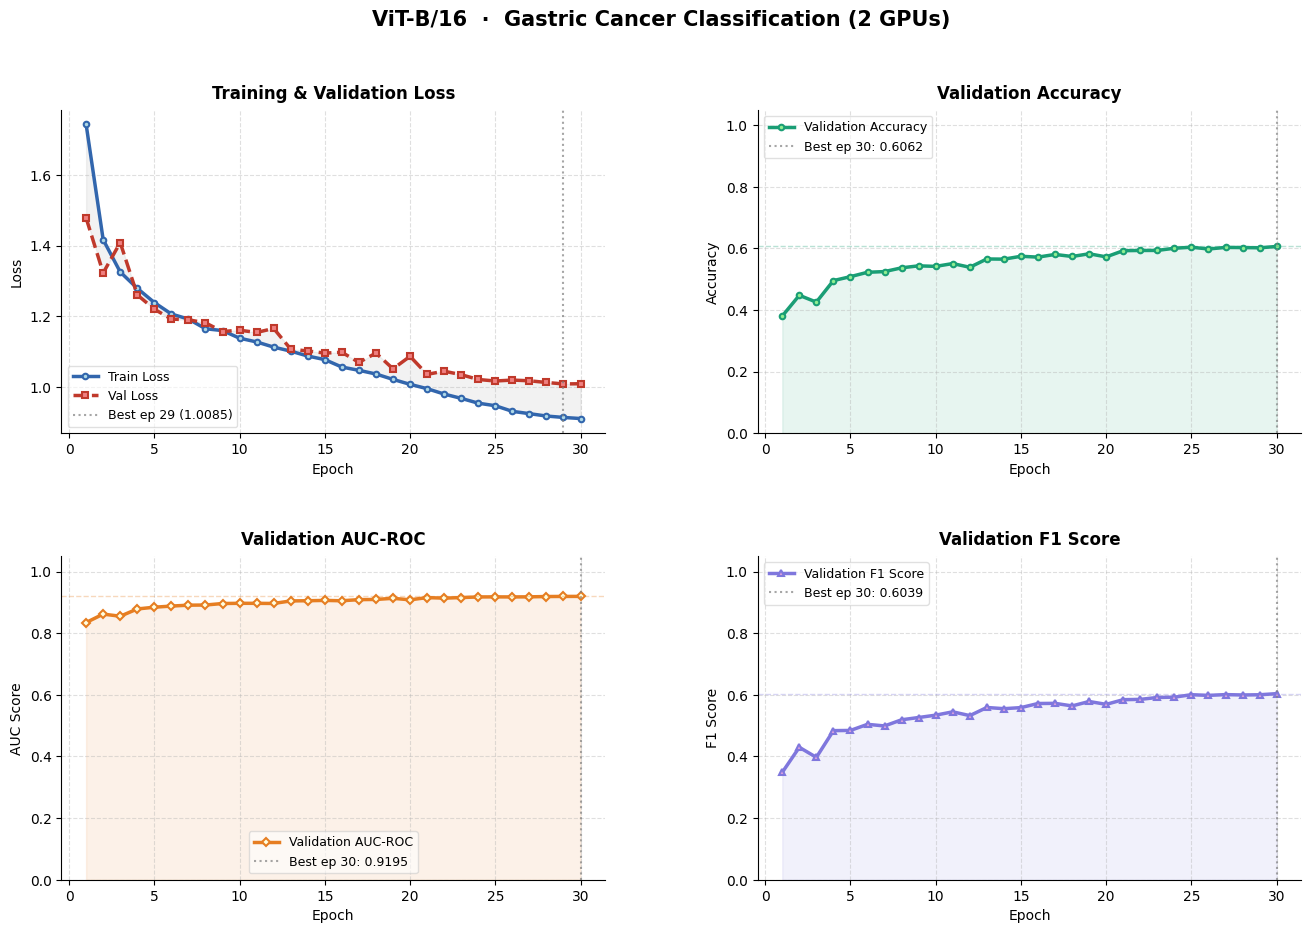


📊 Training Summary: ViT-B/16
  Total Epochs     : 30"
  Best Val Loss    : 1.0085 @ Epoch 29
  Best Val Acc     : 0.6062 @ Epoch 30
  Best Val AUC     : 0.9195 @ Epoch 30
  Best Val F1      : 0.6039 @ Epoch 30
  GPU(s) Used      : 2")

Figure saved → /kaggle/working/saved_models/ViT-B-16_curves.png")



In [17]:
model_vit, history_vit = run_training('vit')
plot_history(history_vit, 'ViT-B/16')

In [19]:
def evaluate_model(model, data_loader, model_name: str = 'Model'):
    """
    Evaluate model on test/validation set and generate comprehensive metrics.
    
    Args:
        model       : Trained model (may be wrapped with DataParallel)
        data_loader : DataLoader for evaluation
        model_name  : Display name for the model
    
    Returns:
        Dict with all metrics (accuracy, precision, recall, f1, auc, etc.)
    """
    from sklearn.metrics import (
        confusion_matrix, classification_report, roc_curve, auc,
        precision_score, recall_score, f1_score as f1_score_sklearn,
        roc_auc_score
    )
    
    print(f"\n{'='*60}")
    print(f"  Evaluating {model_name}")
    print(f"{'='*60}\n")
    
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Evaluating", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    # ── Calculate metrics ──────────────────────────────────────────────────
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score_sklearn(all_labels, all_preds, average='macro', zero_division=0)
    
    try:
        auc_score = roc_auc_score(
            all_labels, all_probs,
            multi_class='ovr',
            average='macro'
        )
    except:
        auc_score = 0.0
    
    # ── Confusion Matrix ───────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    
    # ── Classification Report ──────────────────────────────────────────────
    class_report = classification_report(
        all_labels, all_preds,
        target_names=[str(i) for i in range(NUM_CLASSES)],
        zero_division=0
    )
    
    # ── Print Results ──────────────────────────────────────────────────────
    print(f"📊 Overall Metrics:")
    print(f"{'─'*60}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  Precision  : {precision:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  F1 Score   : {f1:.4f}")
    print(f"  AUC-ROC    : {auc_score:.4f}")
    print(f"{'─'*60}\n")
    
    print(f"📋 Classification Report:")
    print(f"{'─'*60}")
    print(class_report)
    print(f"{'─'*60}\n")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc_score,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'probabilities': all_probs,
        'labels': all_labels,
        'classification_report': class_report
    }


def plot_confusion_matrix(cm, model_name: str = 'Model'):
    """
    Plot confusion matrix as heatmap.
    
    Args:
        cm         : Confusion matrix from evaluate_model()
        model_name : Display name for the model
    """
    from sklearn.metrics import ConfusionMatrixDisplay
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    
    # Set labels and title
    ax.set_title(
        f'{model_name} - Confusion Matrix\n{NUM_GPUS} GPU(s)',
        fontsize=14, fontweight='bold', pad=20
    )
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    
    # Set ticks
    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(tick_marks)
    ax.set_yticklabels(tick_marks)
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Count')
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black",
                   fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    out_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "-")}_confusion_matrix.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Confusion matrix saved → {out_path}\n")


def plot_roc_curves(eval_results, model_name: str = 'Model'):
    """
    Plot ROC curves for each class (One-vs-Rest).
    
    Args:
        eval_results : Dict returned by evaluate_model()
        model_name   : Display name for the model
    """
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    
    y_true = eval_results['labels']
    y_probs = eval_results['probabilities']
    
    # Binarize labels for ROC calculation
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
    
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, lw=2.5, label=f'Class {i} (AUC = {roc_auc:.3f})',
               color=colors[i], marker='o', markersize=4, markevery=5)
    
    # Diagonal line (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier', alpha=0.5)
    
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - ROC Curves (One-vs-Rest)\n{NUM_GPUS} GPU(s)',
                fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    
    plt.tight_layout()
    
    # Save figure
    out_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "-")}_roc_curves.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ ROC curves saved → {out_path}\n")


def plot_metrics_comparison(eval_results, model_name: str = 'Model'):
    """
    Plot bar charts for Precision, Recall, F1 per class.
    
    Args:
        eval_results : Dict returned by evaluate_model()
        model_name   : Display name for the model
    """
    from sklearn.metrics import precision_recall_fscore_support
    
    y_true = eval_results['labels']
    y_pred = eval_results['predictions']
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    
    x = np.arange(NUM_CLASSES)
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    bars1 = ax.bar(x - width, precision, width, label='Precision', color='#3498db', edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x,         recall,    width, label='Recall',    color='#e74c3c', edgecolor='black', linewidth=1.5)
    bars3 = ax.bar(x + width, f1,        width, label='F1 Score',  color='#2ecc71', edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    add_value_labels(bars1)
    add_value_labels(bars2)
    add_value_labels(bars3)
    
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} - Per-Class Metrics\n{NUM_GPUS} GPU(s)',
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Class {i}' for i in range(NUM_CLASSES)])
    ax.legend(fontsize=11, framealpha=0.9)
    ax.set_ylim([0, 1.1])
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    # Save figure
    out_path = os.path.join(SAVE_DIR, f'{model_name.replace("/", "-")}_metrics_comparison.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Metrics comparison saved → {out_path}\n")


print("✅ Evaluation functions defined (Confusion Matrix, ROC, Metrics).")

✅ Evaluation functions defined (Confusion Matrix, ROC, Metrics).



  Evaluating ViT-B/16



Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

📊 Overall Metrics:
────────────────────────────────────────────────────────────
  Accuracy   : 0.5940
  Precision  : 0.5997
  Recall     : 0.5947
  F1 Score   : 0.5929
  AUC-ROC    : 0.9174
────────────────────────────────────────────────────────────

📋 Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.73      0.69      0.71       785
           1       0.42      0.56      0.48       800
           2       0.70      0.84      0.77       764
           3       0.59      0.61      0.60       803
           4       0.77      0.63      0.70       766
           5       0.46      0.35      0.40       796
           6       0.56      0.48      0.51       750
           7       0.55      0.58      0.57       755

    accuracy                           0.59      6219
   macro avg       0.60      0.59      0.59      6219
weighted avg       0.60      0.59      0.59      6219

───────────

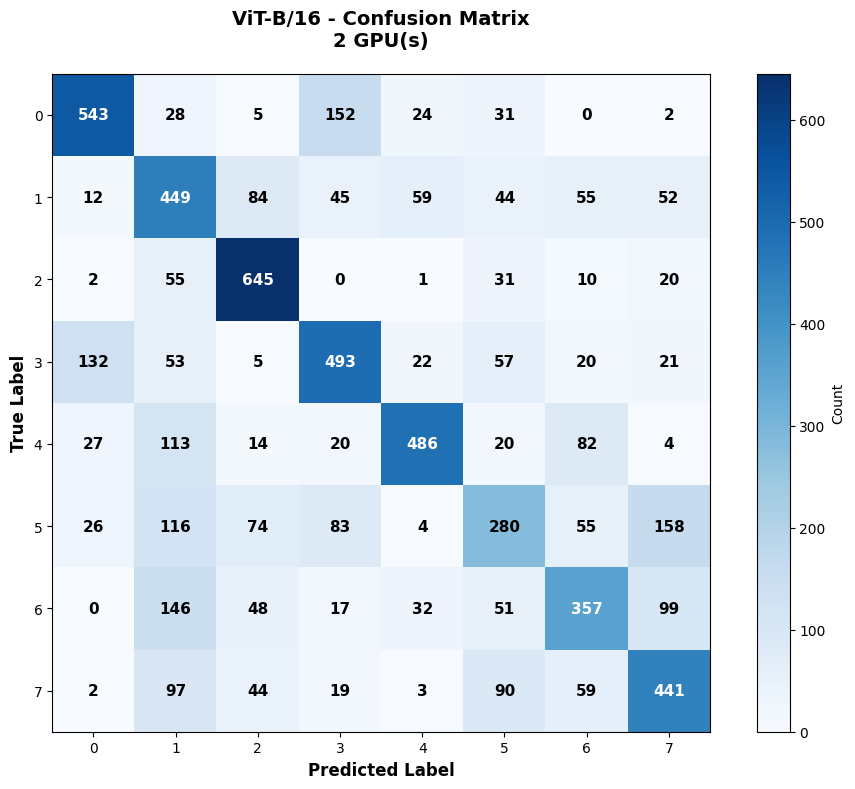

✅ Confusion matrix saved → /kaggle/working/saved_models/ViT-B-16_confusion_matrix.png



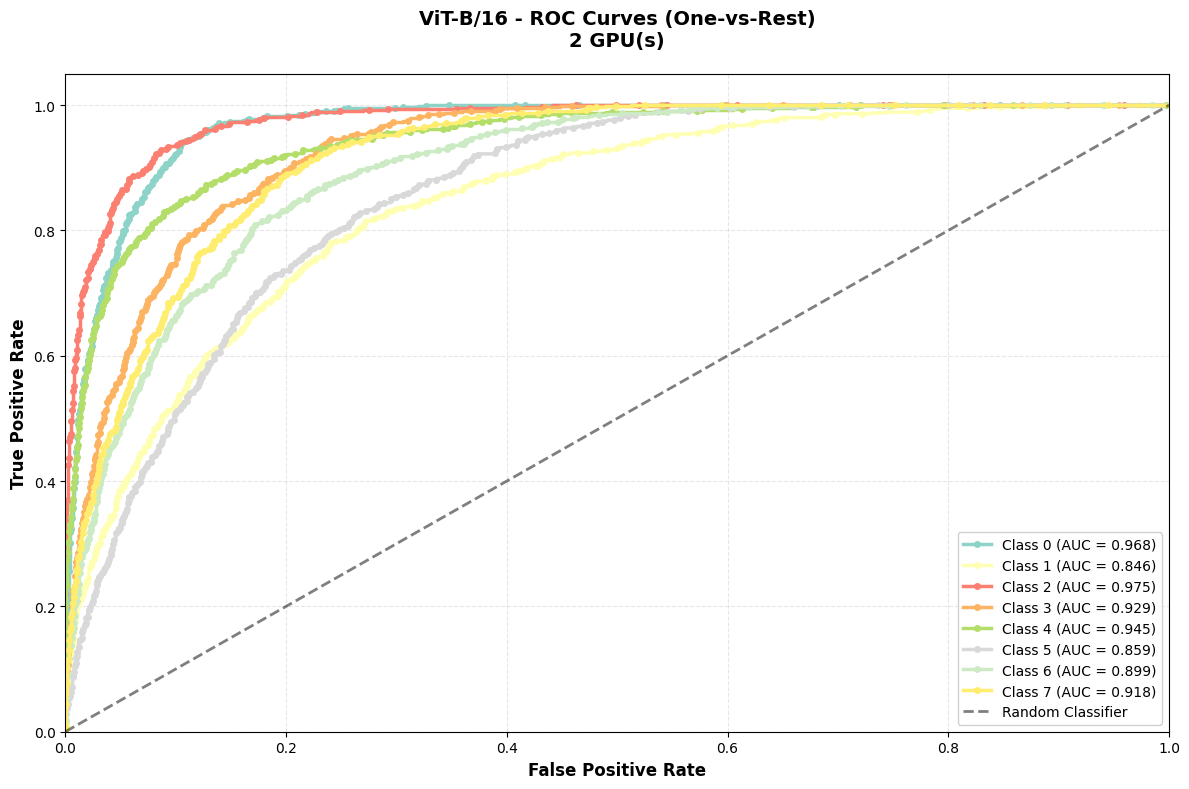

✅ ROC curves saved → /kaggle/working/saved_models/ViT-B-16_roc_curves.png



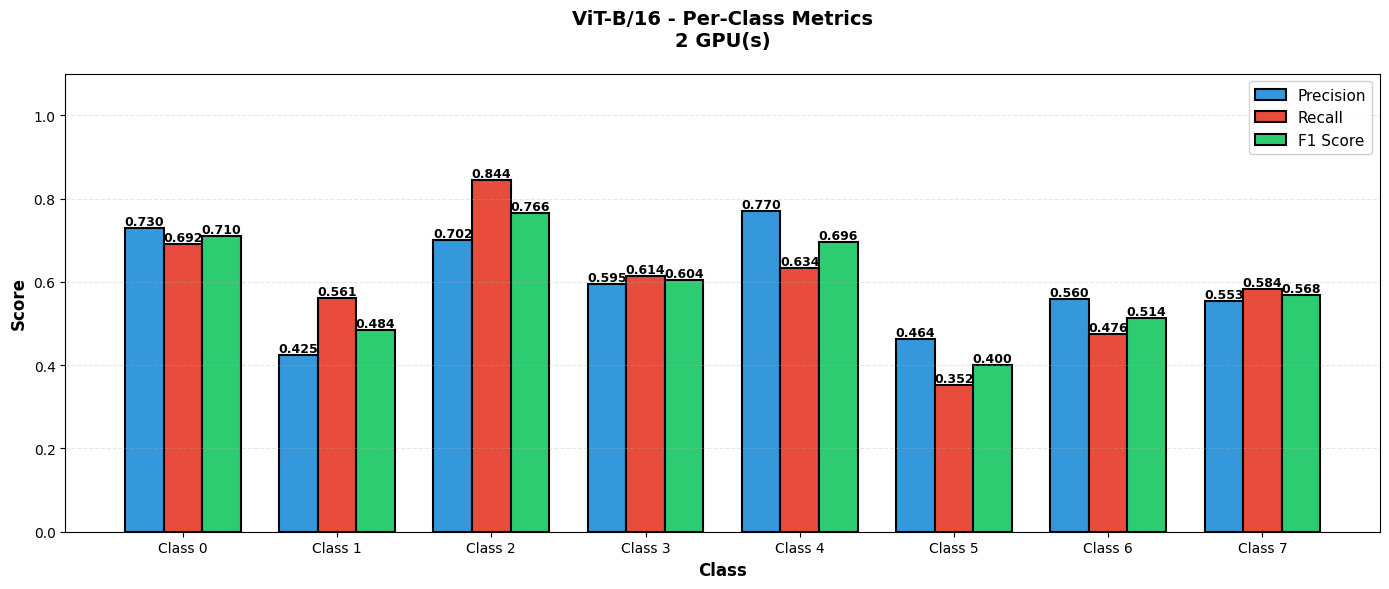

✅ Metrics comparison saved → /kaggle/working/saved_models/ViT-B-16_metrics_comparison.png


✅ ViT-B/16 evaluation complete!

 All models trained and evaluated successfully with multi-GPU support!


In [20]:
# Evaluate
eval_vit = evaluate_model(model_vit, val_loader, 'ViT-B/16')
plot_confusion_matrix(eval_vit['confusion_matrix'], 'ViT-B/16')
plot_roc_curves(eval_vit, 'ViT-B/16')
plot_metrics_comparison(eval_vit, 'ViT-B/16')

print("\n" + "="*60)
print("✅ ViT-B/16 evaluation complete!")
print("="*60)

print("\n" + "="*70)
print(" All models trained and evaluated successfully with multi-GPU support!")
print("="*70)


  Training  B0
Classes found : 8
Class names   : ['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']
Total images  : 31096

NUM_CLASSES set to: 8
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s] 


🚀 Wrapping model with DataParallel (2 GPUs)...
✅ Model wrapped successfully!



Ep 01 Train:   0%|          | 0/195 [00:00<?, ?it/s]

Ep 01 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

...

Ep 09 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

Ep 09 | Loss 0.6041/0.6769 | Acc 0.7471 | AUC 0.9668 | F1 0.7436 | LR 0.000794
    ⏳ No improvement (4/5)


Ep 10 Train:   0%|          | 0/195 [00:00<?, ?it/s]

Ep 10 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

Ep 10 | Loss 0.5896/0.6699 | Acc 0.7461 | AUC 0.9690 | F1 0.7433 | LR 0.000750
    ⏳ No improvement (5/5)
    🛑 Early stopping at epoch 10

  B0 done | Best val loss: 0.6693



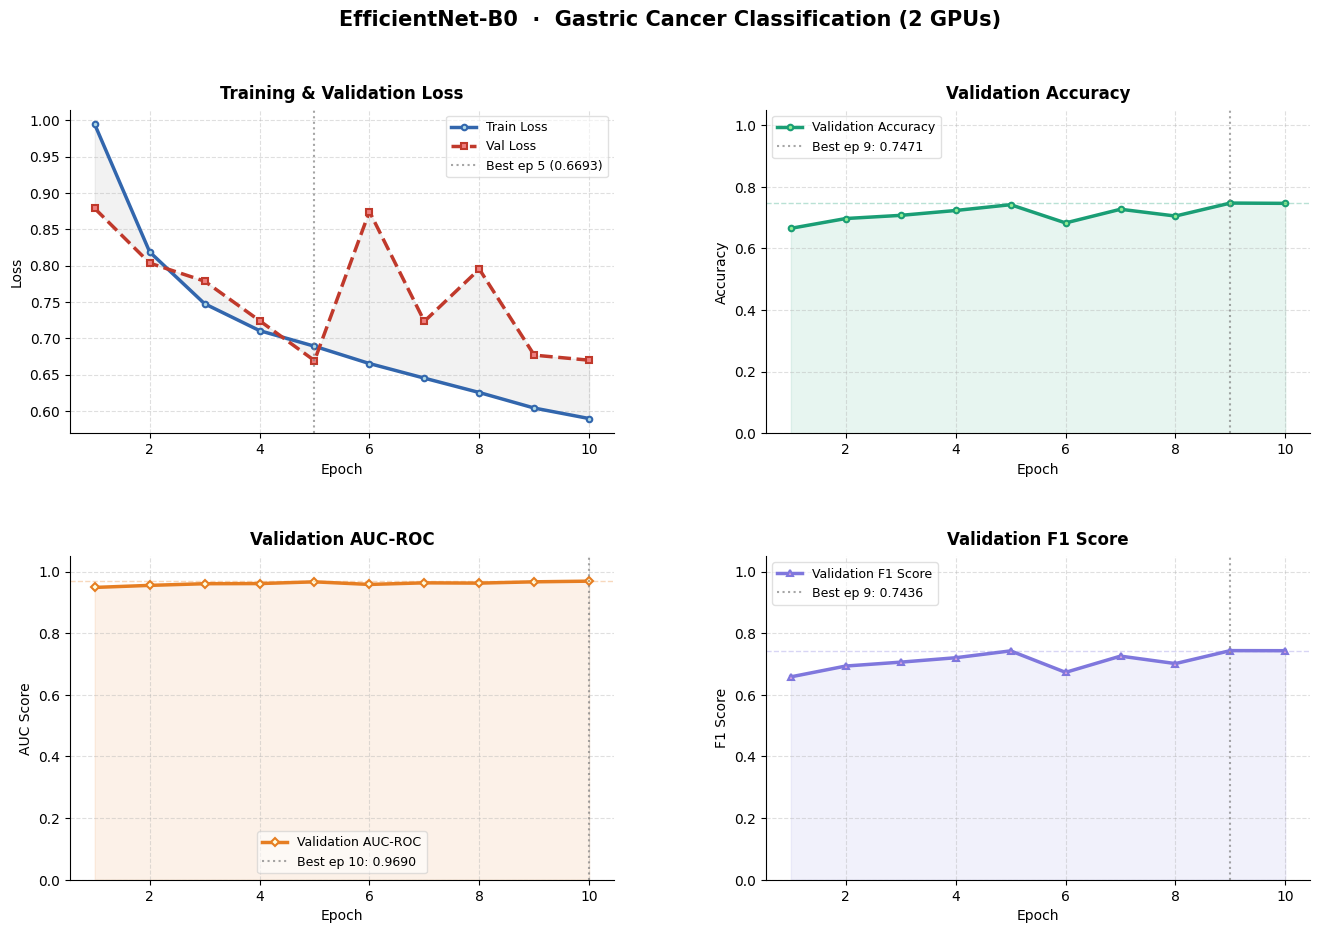


📊 Training Summary: EfficientNet-B0
  Total Epochs     : 10"
  Best Val Loss    : 0.6693 @ Epoch 5
  Best Val Acc     : 0.7471 @ Epoch 9
  Best Val AUC     : 0.9690 @ Epoch 10
  Best Val F1      : 0.7436 @ Epoch 9
  GPU(s) Used      : 2")

Figure saved → /kaggle/working/saved_models/EfficientNet-B0_curves.png")



In [21]:
# ── EfficientNet-B0 ────────────────────────────────────────────────────────
model_b0, history_b0 = run_training('b0')
plot_history(history_b0, 'EfficientNet-B0')


  Evaluating EfficientNet-B0



Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

📊 Overall Metrics:
────────────────────────────────────────────────────────────
  Accuracy   : 0.7461
  Precision  : 0.7529
  Recall     : 0.7451
  F1 Score   : 0.7433
  AUC-ROC    : 0.9690
────────────────────────────────────────────────────────────

📋 Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       785
           1       0.67      0.84      0.74       800
           2       0.80      0.89      0.84       764
           3       0.70      0.82      0.76       803
           4       0.77      0.84      0.81       766
           5       0.70      0.66      0.68       796
           6       0.71      0.61      0.66       750
           7       0.77      0.58      0.66       755

    accuracy                           0.75      6219
   macro avg       0.75      0.75      0.74      6219
weighted avg       0.75      0.75      0.74      6219

───────────

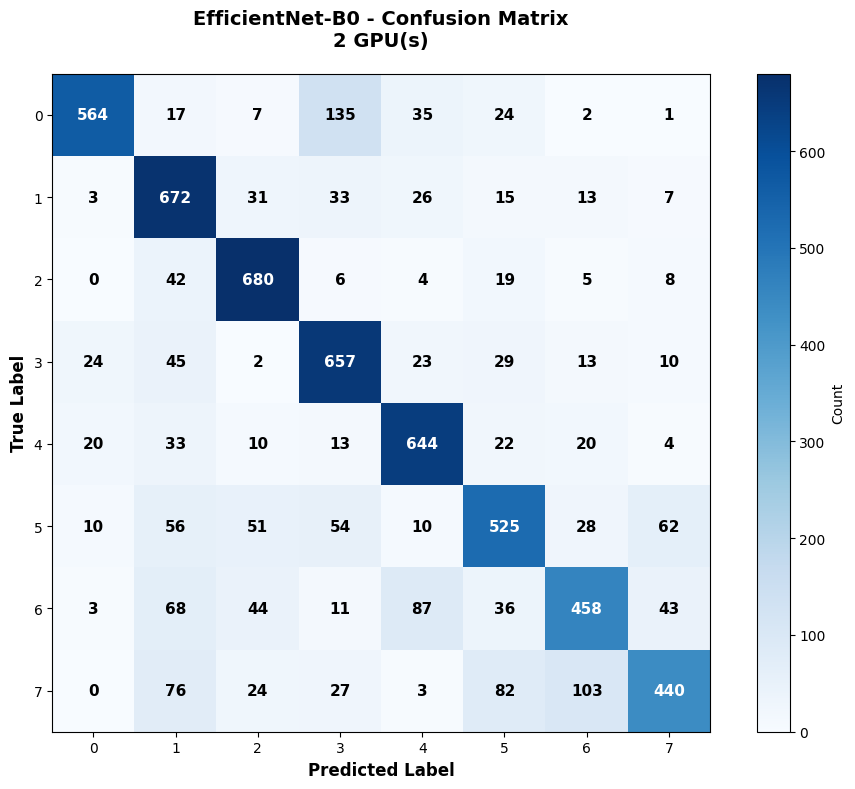

✅ Confusion matrix saved → /kaggle/working/saved_models/EfficientNet-B0_confusion_matrix.png



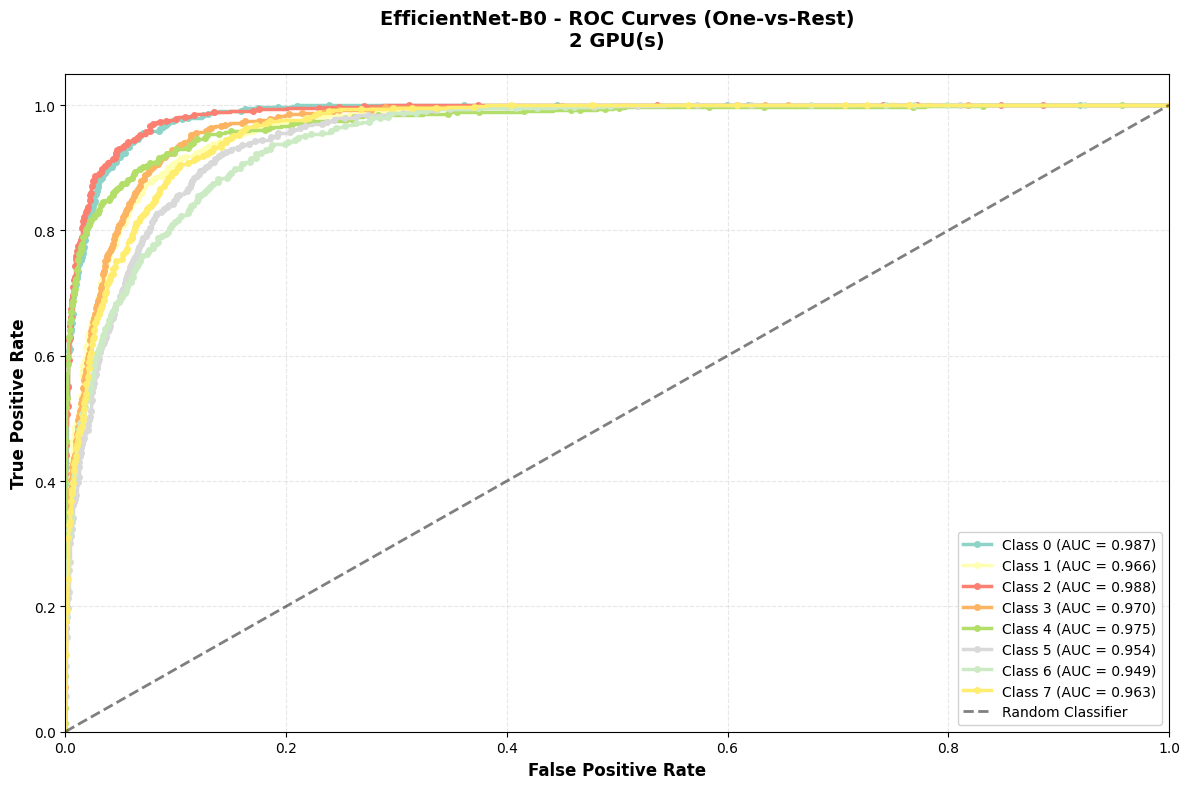

✅ ROC curves saved → /kaggle/working/saved_models/EfficientNet-B0_roc_curves.png



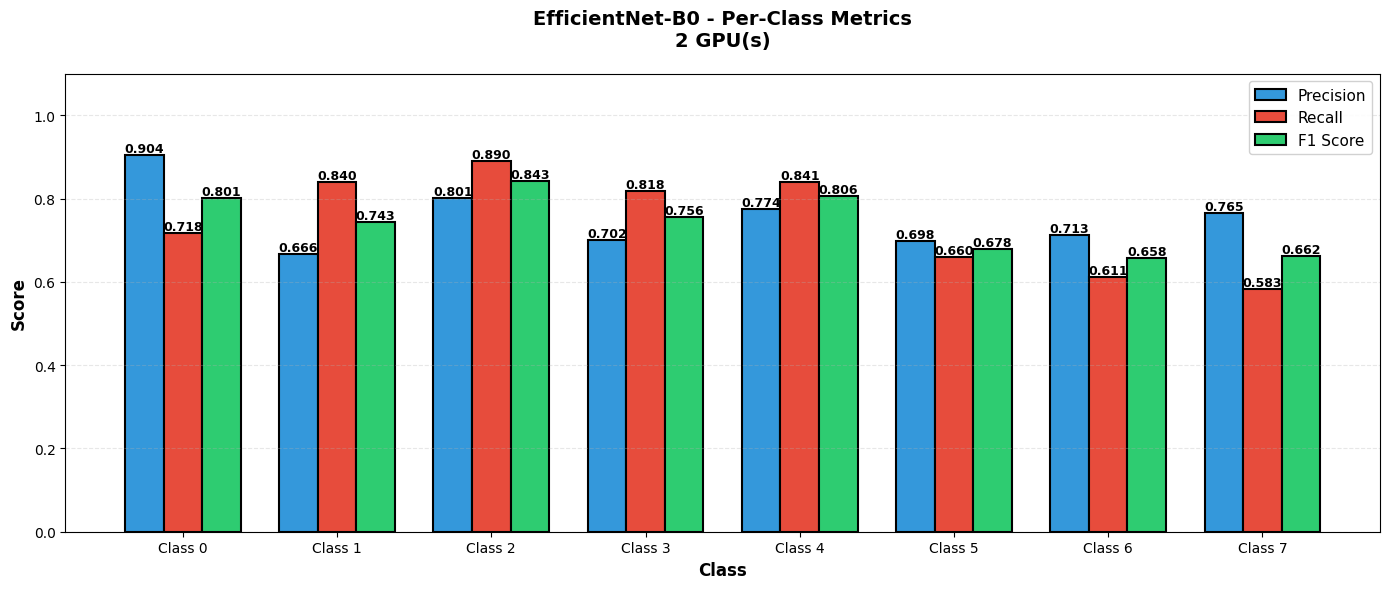

✅ Metrics comparison saved → /kaggle/working/saved_models/EfficientNet-B0_metrics_comparison.png


✅ EfficientNet-B0 evaluation complete!


In [22]:
# Evaluate and generate metrics
eval_b0 = evaluate_model(model_b0, val_loader, 'EfficientNet-B0')
plot_confusion_matrix(eval_b0['confusion_matrix'], 'EfficientNet-B0')
plot_roc_curves(eval_b0, 'EfficientNet-B0')
plot_metrics_comparison(eval_b0, 'EfficientNet-B0')

print("\n" + "="*60)
print("✅ EfficientNet-B0 evaluation complete!")
print("="*60)


  Training  V2_S
Classes found : 8
Class names   : ['ADI', 'DEB', 'LYM', 'MUC', 'MUS', 'NOR', 'STR', 'TUM']
Total images  : 31096

NUM_CLASSES set to: 8
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 187MB/s] 



🚀 Wrapping model with DataParallel (2 GPUs)...
✅ Model wrapped successfully!



Ep 01 Train:   0%|          | 0/195 [00:00<?, ?it/s]

Ep 01 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

...

Ep 24 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

Ep 24 | Loss 0.3522/0.6527 | Acc 0.7676 | AUC 0.9725 | F1 0.7657 | LR 0.000095
    ⏳ No improvement (4/5)


Ep 25 Train:   0%|          | 0/195 [00:00<?, ?it/s]

Ep 25 Val  :   0%|          | 0/49 [00:00<?, ?it/s]

Ep 25 | Loss 0.3288/0.6600 | Acc 0.7723 | AUC 0.9723 | F1 0.7717 | LR 0.000067
    ⏳ No improvement (5/5)
    🛑 Early stopping at epoch 25

  V2_S done | Best val loss: 0.6308



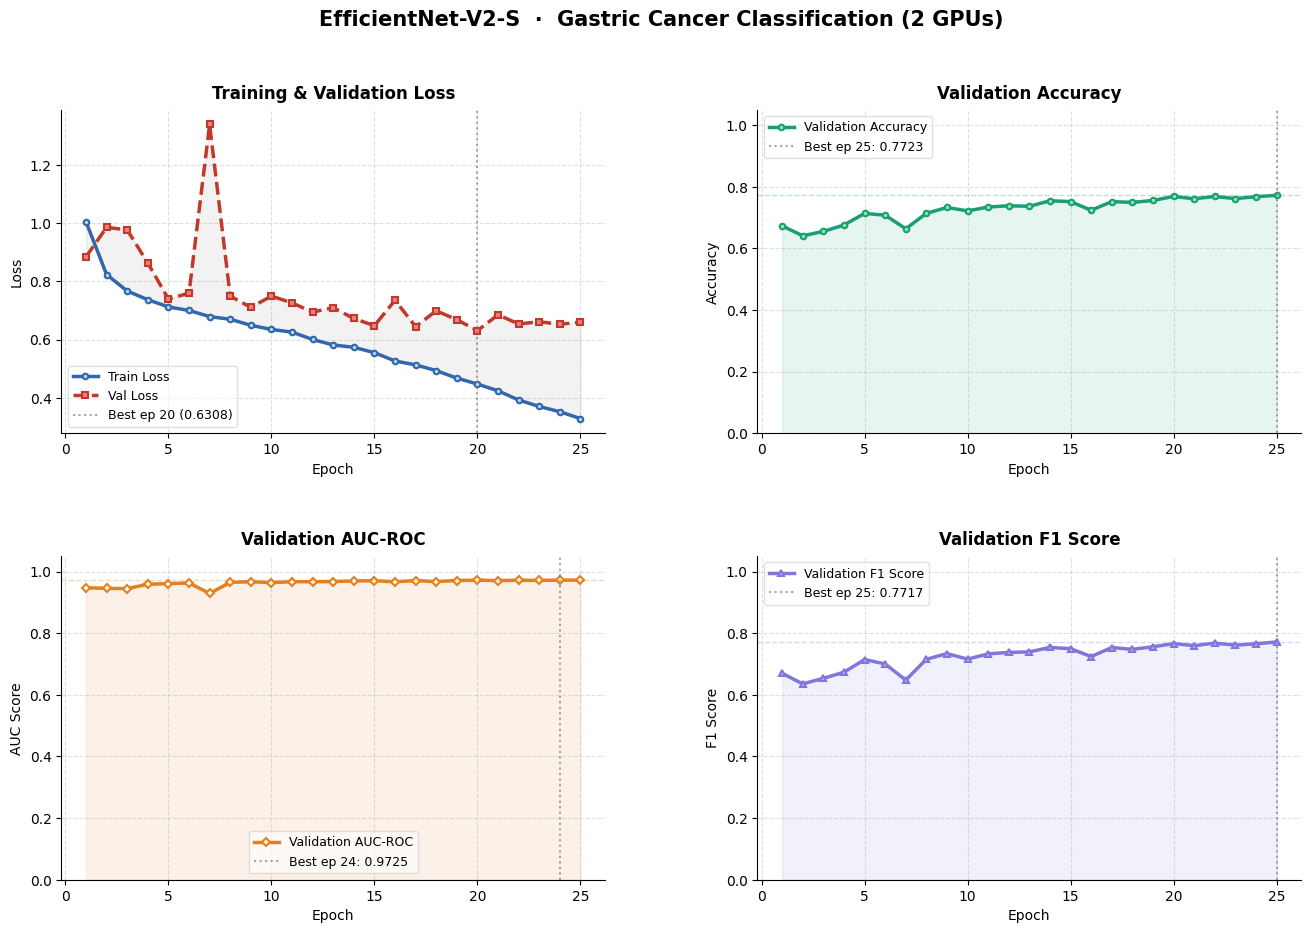


📊 Training Summary: EfficientNet-V2-S
  Total Epochs     : 25"
  Best Val Loss    : 0.6308 @ Epoch 20
  Best Val Acc     : 0.7723 @ Epoch 25
  Best Val AUC     : 0.9725 @ Epoch 24
  Best Val F1      : 0.7717 @ Epoch 25
  GPU(s) Used      : 2")

Figure saved → /kaggle/working/saved_models/EfficientNet-V2-S_curves.png")



In [23]:
# ── EfficientNet-V2-S ──────────────────────────────────────────────────────
model_v2s, history_v2s = run_training('v2_s')
plot_history(history_v2s, 'EfficientNet-V2-S')


  Evaluating EfficientNet-V2-S



Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

📊 Overall Metrics:
────────────────────────────────────────────────────────────
  Accuracy   : 0.7723
  Precision  : 0.7748
  Recall     : 0.7725
  F1 Score   : 0.7717
  AUC-ROC    : 0.9723
────────────────────────────────────────────────────────────

📋 Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       785
           1       0.73      0.78      0.75       800
           2       0.82      0.90      0.86       764
           3       0.75      0.82      0.78       803
           4       0.85      0.77      0.81       766
           5       0.77      0.63      0.69       796
           6       0.70      0.72      0.71       750
           7       0.71      0.76      0.73       755

    accuracy                           0.77      6219
   macro avg       0.77      0.77      0.77      6219
weighted avg       0.77      0.77      0.77      6219

───────────

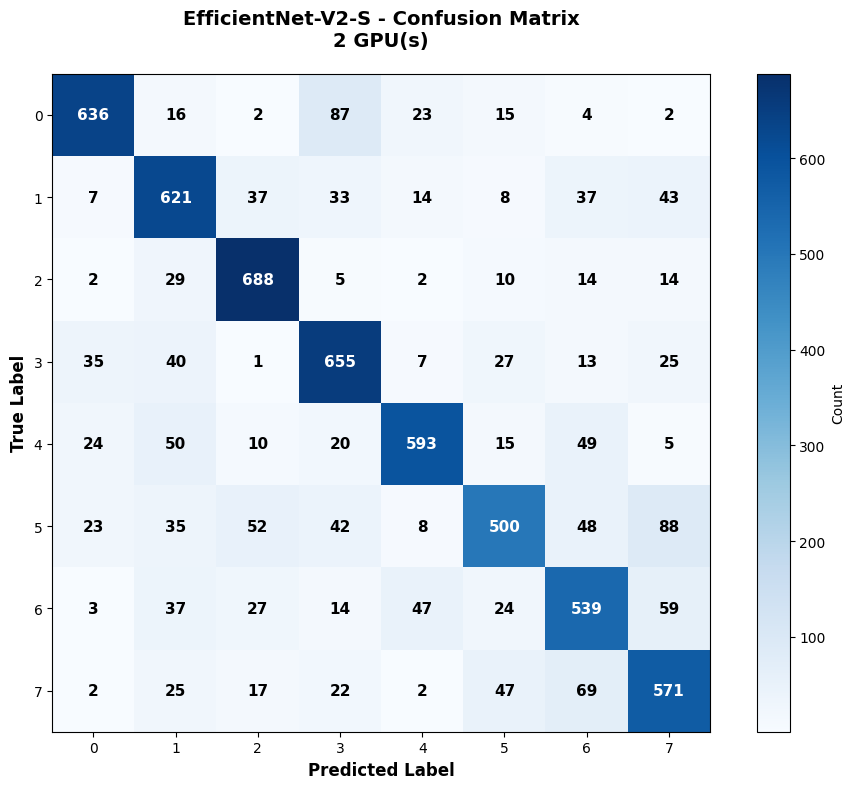

✅ Confusion matrix saved → /kaggle/working/saved_models/EfficientNet-V2-S_confusion_matrix.png



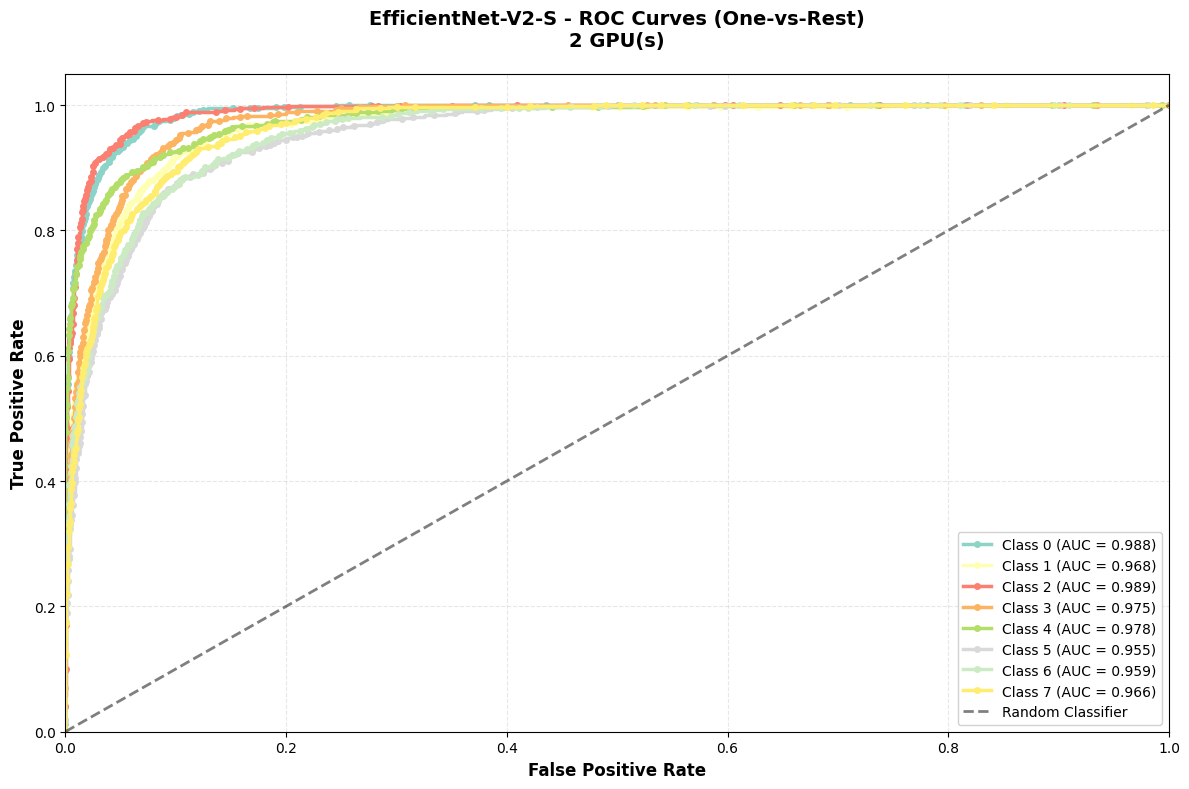

✅ ROC curves saved → /kaggle/working/saved_models/EfficientNet-V2-S_roc_curves.png



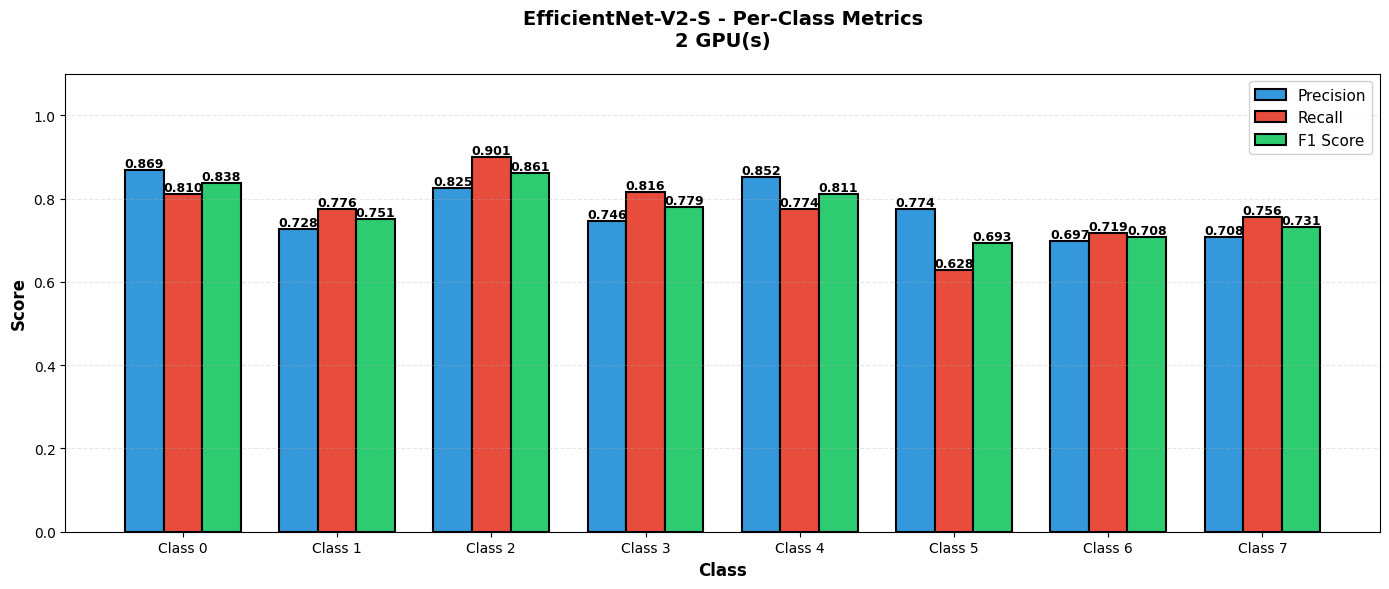

✅ Metrics comparison saved → /kaggle/working/saved_models/EfficientNet-V2-S_metrics_comparison.png


✅ EfficientNet-V2-S evaluation complete!


In [24]:
# Evaluate
eval_v2s = evaluate_model(model_v2s, val_loader, 'EfficientNet-V2-S')
plot_confusion_matrix(eval_v2s['confusion_matrix'], 'EfficientNet-V2-S')
plot_roc_curves(eval_v2s, 'EfficientNet-V2-S')
plot_metrics_comparison(eval_v2s, 'EfficientNet-V2-S')

print("\n" + "="*60)
print("✅ EfficientNet-V2-S evaluation complete!")
print("="*60)
